# **S&P 500 ESG Risk Rating Predictor**
Sarah Jacquemin, Yasmin Owen, Roman Wallerand

In [1]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import kagglehub
import yfinance as yf
import wordcloud

from scipy.sparse import hstack, csr_matrix

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from transformers import pipeline

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
CACHE_PATH   = "financial_data_cache_2.csv"

In [2]:
# ── 1. Data loading ───────────────────────────────────────────────────────────
path = kagglehub.dataset_download("pritish509/s-and-p-500-esg-risk-ratings")
print("Dataset path:", path)

csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]
if not csv_files:
    raise FileNotFoundError(f"No CSV file found in {path}")

df = pd.read_csv(os.path.join(path, csv_files[0]))
print(f"Loaded {len(df)} rows × {len(df.columns)} columns")
print(df.head())


100%|██████████| 247k/247k [00:00<00:00, 786kB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/pritish509/s-and-p-500-esg-risk-ratings/versions/2
Loaded 503 rows × 15 columns
  Symbol                      Name  \
0   ENPH      Enphase Energy, Inc.   
1    EMN  Eastman Chemical Company   
2    DPZ       Domino's Pizza Inc.   
3    DAY            Dayforce, Inc.   
4    DVA               Davita Inc.   

                                             Address             Sector  \
0  47281 Bayside Parkway\nFremont, CA 94538\nUnit...         Technology   
1  200 South Wilcox Drive\nKingsport, TN 37662\nU...    Basic Materials   
2  30 Frank Lloyd Wright Drive\nAnn Arbor, MI 481...  Consumer Cyclical   
3  3311 East Old Shakopee Road\nMinneapolis, MN 5...         Technology   
4  2000 16th Street\nDenver, CO 80202\nUnited States         Healthcare   

                  Industry Full Time Employees  \
0                    Solar               3,157   
1      Specialty Chemicals              14,000   
2              Restauran

In [3]:
# ── 2. Preprocessing ──────────────────────────────────────────────────────────
df_clean = df.dropna(subset=["ESG Risk Level"]).copy()

# Clean employees column ("45,000" → 45000.0)
df_clean["Full Time Employees"] = (
    df_clean["Full Time Employees"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .replace("nan", np.nan)
    .astype(float)
)

df_clean["Description"] = df_clean["Description"].fillna("")

# Simplify target: 5 levels → 3 (single source of truth)
target = df_clean["ESG Risk Level"].replace({"Severe": "High", "Negligible": "Low"})

# feature engineering to separate energy types
kws_renewable = "solar|wind|renewable|hydro|clean energy"
kws_fossil = "oil|gas|coal|petroleum|exploration|refining"

# 1 if word present or 0 if not
df_clean["is_renewable"] = df_clean["Description"].str.contains(kws_renewable, case=False, regex=True).astype(int)
df_clean["is_fossil"] = df_clean["Description"].str.contains(kws_fossil, case=False, regex=True).astype(int)

# If fossil & renewable mentionned: both taken into account

print("\nBreakdown of the new energy variables :")
print("Renewable energy companies :", df_clean["is_renewable"].sum())
print("Fossil energy companies :", df_clean["is_fossil"].sum())

print("Target distribution:")
print(target.value_counts())
print(f"\nClass balance: {(target.value_counts() / len(target) * 100).round(1).to_dict()}")



Breakdown of the new energy variables :
Renewable energy companies : 59
Fossil energy companies : 110
Target distribution:
ESG Risk Level
Low       193
Medium    184
High       53
Name: count, dtype: int64

Class balance: {'Low': 44.9, 'Medium': 42.8, 'High': 12.3}



── Wordclouds Generation ──


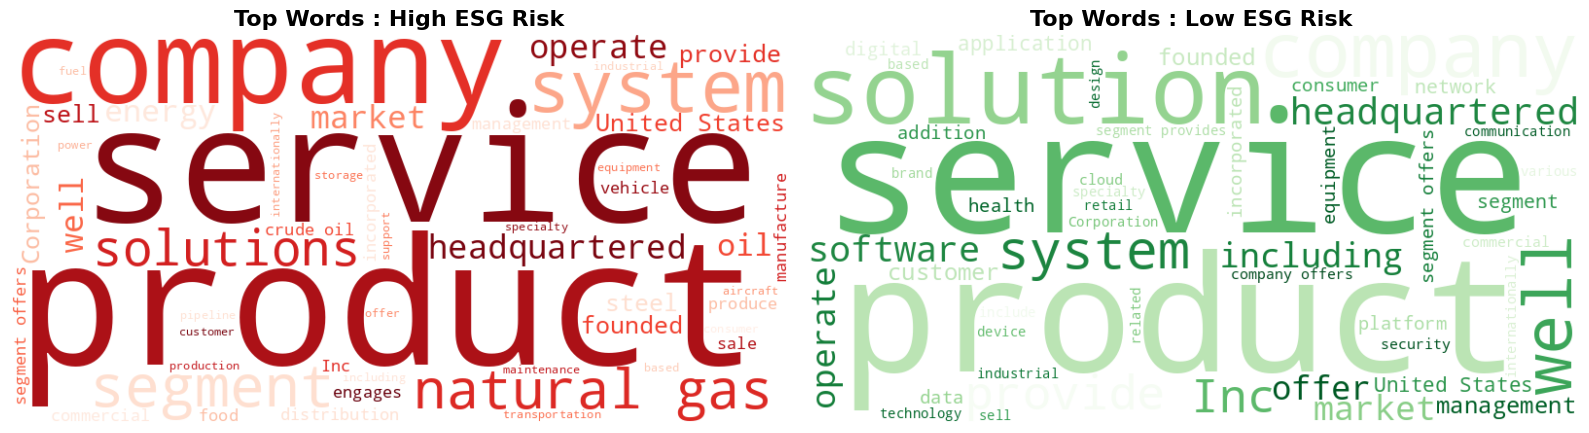

Saved: wordclouds_esg.png


In [4]:
import wordcloud
# ── 2.5 Data Exploration: WordClouds ───────────────────────
print("\n── Wordclouds Generation ──")

# We group the texts by ESG risk level
# We use the ‘target’ variable that we created in step 2
text_high = " ".join(df_clean[target == "High"]["Description"].dropna())
text_low = " ".join(df_clean[target == "Low"]["Description"].dropna())

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# High-Risk Cloud (in red)
wc_high = wordcloud.WordCloud(width=800, height=400, background_color='white', colormap='Reds', max_words=50).generate(text_high)
axes[0].imshow(wc_high, interpolation='bilinear')
axes[0].set_title("Top Words : High ESG Risk", fontsize=16, fontweight='bold')
axes[0].axis('off')

# Low-Risk Cloud (in green)
wc_low = wordcloud.WordCloud(width=800, height=400, background_color='white', colormap='Greens', max_words=50).generate(text_low)
axes[1].imshow(wc_low, interpolation='bilinear')
axes[1].set_title("Top Words : Low ESG Risk", fontsize=16, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig("wordclouds_esg.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: wordclouds_esg.png")

In [5]:
# ── 3. Train / test split (before fitting) ────────────────────
# We split the raw df_clean so that all preprocessing is done post-split.
# idx_train / idx_test carry original indices for later alignment.
(
    X_raw_train, X_raw_test,
    y_train,     y_test,
    idx_train,   idx_test,
) = train_test_split(
    df_clean,
    target,
    df_clean.index,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=target,
)

print(f"Train: {len(y_train)} rows  |  Test: {len(y_test)} rows")
print("Train class distribution:", y_train.value_counts().to_dict())


Train: 344 rows  |  Test: 86 rows
Train class distribution: {'Low': 155, 'Medium': 147, 'High': 42}


In [6]:
# ── 4. Baseline pipeline: structured features only ────────────────────────────
#
# OneHotEncoder fitted on training data only.
# pd.get_dummies on the full dataset encodes all categories seen globally,
# including test-only categories, subtle form of leakage.
# OneHotEncoder with handle_unknown='ignore' safely handles unseen categories at test time.
#
# SimpleImputer and StandardScaler inside the pipeline.


cat_features = ["Sector", "Industry"]
num_features = ["Full Time Employees", "is_renewable", "is_fossil"]

preprocessor_baseline = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), cat_features),
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ]), num_features),
])

pipeline_baseline = Pipeline([
    ("preprocessor", preprocessor_baseline),
    ("clf", RandomForestClassifier(
        n_estimators=200,         # more trees, more stable
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1,                # use all CPU cores
    )),
])

# IMPROVEMENT: 5-fold cross-validation on the training set
# A single 80/20 split gives one data point. CV gives 5 and shows variance.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores_baseline = cross_val_score(
    pipeline_baseline, X_raw_train[cat_features + num_features],
    y_train, cv=cv, scoring="f1_macro", n_jobs=-1
)
print(f"Baseline CV F1-macro: {cv_scores_baseline.mean():.3f} ± {cv_scores_baseline.std():.3f}")

# Final fit on full train set, evaluate on held-out test
pipeline_baseline.fit(X_raw_train[cat_features + num_features], y_train)
y_pred_baseline = pipeline_baseline.predict(X_raw_test[cat_features + num_features])

print("\n── Baseline model (sector + industry + employees) ──")
print(classification_report(y_test, y_pred_baseline))


Baseline CV F1-macro: 0.625 ± 0.031

── Baseline model (sector + industry + employees) ──
              precision    recall  f1-score   support

        High       0.55      0.55      0.55        11
         Low       0.63      0.76      0.69        38
      Medium       0.66      0.51      0.58        37

    accuracy                           0.63        86
   macro avg       0.61      0.61      0.60        86
weighted avg       0.63      0.63      0.62        86



In [7]:
# ── 5. NLP features: TF-IDF on company description ───────────────────────────
#
# The TF-IDF vectorizer is fit on training descriptions only.
# We then combine TF-IDF sparse matrix with the structured feature matrix
# using scipy.sparse.hstack.

tfidf = TfidfVectorizer(stop_words="english", max_features=300, min_df=2)

X_train_text = tfidf.fit_transform(X_raw_train["Description"])
X_test_text  = tfidf.transform(X_raw_test["Description"])

# Extract structured features (as sparse) from the fitted baseline preprocessor
X_train_struct = pipeline_baseline.named_steps["preprocessor"].transform(
    X_raw_train[cat_features + num_features]
)
X_test_struct  = pipeline_baseline.named_steps["preprocessor"].transform(
    X_raw_test[cat_features + num_features]
)

X_train_nlp = hstack([X_train_struct, X_train_text])
X_test_nlp  = hstack([X_test_struct,  X_test_text])
print("Combined feature matrix (train) shape:", X_train_nlp.shape)

rf_nlp = RandomForestClassifier(
    n_estimators=200, random_state=RANDOM_STATE,
    class_weight="balanced", n_jobs=-1
)
rf_nlp.fit(X_train_nlp, y_train)
y_pred_nlp = rf_nlp.predict(X_test_nlp)

print("\n── NLP model (structured + TF-IDF descriptions) ──")
print(classification_report(y_test, y_pred_nlp))


Combined feature matrix (train) shape: (344, 418)

── NLP model (structured + TF-IDF descriptions) ──
              precision    recall  f1-score   support

        High       0.43      0.27      0.33        11
         Low       0.62      0.76      0.68        38
      Medium       0.62      0.54      0.58        37

    accuracy                           0.60        86
   macro avg       0.56      0.53      0.53        86
weighted avg       0.60      0.60      0.59        86



In [8]:
# ── 5.5 NLP Zero-Shot Model (Hugging Face) ───────────────────────────
print("\n── Loading the Zero-Shot model (BART-MNLI) ──")
# Using bart-large-mnli, which is an industry standard for Zero-Shot classification
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# Define the candidate labels in plain English for the model to understand
candidate_labels = ["Low ESG Risk", "Medium ESG Risk", "High ESG Risk"]

# Zero-Shot inference is computationally expensive.
# We will ONLY test it on the test set (X_raw_test) to evaluate its performance.
print(f"Running Zero-Shot prediction on {len(X_raw_test)} test set companies (this may take a few minutes)...")

y_pred_zeroshot = []
start_time = time.time()

for i, text in enumerate(X_raw_test["Description"]):
    # If the description is empty, assign a default risk or skip
    if not text.strip():
        y_pred_zeroshot.append("Medium") # Default neutral value
        continue

    # Ask the model to classify the text
    result = classifier(text, candidate_labels)

    # result["labels"][0] contains the top prediction (e.g., "High ESG Risk")
    top_prediction = result["labels"][0]

    # Clean the text to match exactly with your y_test labels ("Low", "Medium", "High")
    clean_pred = top_prediction.replace(" ESG Risk", "")
    y_pred_zeroshot.append(clean_pred)

    # Brief progress output
    if (i + 1) % 20 == 0:
        print(f"  {i + 1}/{len(X_raw_test)} descriptions analyzed...")

print(f"Finished in {round(time.time() - start_time, 1)} seconds.")

print("\n── NLP Zero-Shot Model Results ──")
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_zeroshot))


── Loading the Zero-Shot model (BART-MNLI) ──


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Running Zero-Shot prediction on 86 test set companies (this may take a few minutes)...
  20/86 descriptions analyzed...
  40/86 descriptions analyzed...
  60/86 descriptions analyzed...
  80/86 descriptions analyzed...
Finished in 1058.0 seconds.

── NLP Zero-Shot Model Results ──
              precision    recall  f1-score   support

        High       0.00      0.00      0.00        11
         Low       0.34      0.53      0.41        38
      Medium       0.30      0.22      0.25        37

    accuracy                           0.33        86
   macro avg       0.21      0.25      0.22        86
weighted avg       0.28      0.33      0.29        86



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [9]:
# ── 6. Financial data: fetch from yfinance (with cache) ───────────────────────

# Fetching 500 tickers takes ~4 minutes. If the kernel restarts, we shouldn't
# have to do it again.

FIN_COLS = ["Market Cap", "EBITDA", "Trailing PE", "Beta", "Profit Margin", "Debt To Equity"]

if os.path.exists(CACHE_PATH):
    print(f"Loading financial data from cache: {CACHE_PATH}")
    fin_df = pd.read_csv(CACHE_PATH)
else:
    tickers = df_clean["Symbol"].tolist()
    print(f"Fetching financial data for {len(tickers)} tickers …")
    financial_data = []
    errors = []

    for i, ticker in enumerate(tickers):
        if i > 0 and i % 100 == 0:
            print(f"  {i}/{len(tickers)} fetched … ({len(errors)} errors so far)")
        time.sleep(0.5)

        try:
            info = yf.Ticker(ticker).info
            financial_data.append({
                "Symbol":         ticker,
                "Market Cap":     info.get("marketCap",     np.nan),
                "EBITDA":         info.get("ebitda",         np.nan),
                "Trailing PE":    info.get("trailingPE",    np.nan),
                "Beta":           info.get("beta",           np.nan),
                "Profit Margin":  info.get("profitMargins", np.nan),
                "Debt To Equity": info.get("debtToEquity",  np.nan)
            })
        except Exception as e:
            errors.append({"ticker": ticker, "error": str(e)})
            financial_data.append({
                "Symbol": ticker,
                **{col: np.nan for col in FIN_COLS}
            })

    fin_df = pd.DataFrame(financial_data)
    fin_df.to_csv(CACHE_PATH, index=False)
    print(f"\nDone. {len(errors)} tickers failed:")
    if errors:
        print(pd.DataFrame(errors).to_string(index=False))

df_final = df_clean.merge(fin_df, on="Symbol", how="left")
print("\nMissing values in financial columns:")
print(df_final[FIN_COLS].isna().sum())


Fetching financial data for 430 tickers …


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: WBA"}}}
ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: IPG"}}}


  100/430 fetched … (0 errors so far)


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: PARA"}}}


  200/430 fetched … (0 errors so far)


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: K"}}}
ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: HES"}}}
ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: FI"}}}


  300/430 fetched … (0 errors so far)


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: CMA"}}}
ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ANSS"}}}


  400/430 fetched … (0 errors so far)

Done. 0 tickers failed:

Missing values in financial columns:
Market Cap        12
EBITDA            37
Trailing PE       34
Beta              13
Profit Margin     12
Debt To Equity    56
dtype: int64


In [10]:
# ── 7. Final model: structured + financial + NLP ──────────────────────────────


all_num_features = ["Full Time Employees", "is_renewable", "is_fossil"] + FIN_COLS

preprocessor_final = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), cat_features),
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ]), all_num_features),
])

# Align df_final index to df_clean for consistent loc-based access
df_final = df_final.set_index(df_clean.index)

# Use same train/test split indices as before
df_train_f = df_final.loc[idx_train]
df_test_f  = df_final.loc[idx_test]

# Fit preprocessor on training data only
X_train_sf = preprocessor_final.fit_transform(df_train_f[cat_features + all_num_features])
X_test_sf  = preprocessor_final.transform(df_test_f[cat_features + all_num_features])

# Reuse the already-fitted TF-IDF (no refit)
X_train_text_f = tfidf.transform(df_train_f["Description"])
X_test_text_f  = tfidf.transform(df_test_f["Description"])

# --- SANITY CHECK ---

# 1. Checks that the indices of our features match  the indices of our target (y)
assert (df_train_f.index == y_train.index).all(), "Alerte : L'ordre du Train a été mélangé !"
assert (df_test_f.index == y_test.index).all(), "Alerte : L'ordre du Test a été mélangé !"

# 2. Checks that the number of rows is exactly the same in both matrices
assert X_train_sf.shape[0] == X_train_text_f.shape[0] == len(y_train), "Alerte : Le nombre de lignes ne correspond pas (Train) !"
assert X_test_sf.shape[0] == X_test_text_f.shape[0] == len(y_test), "Alerte : Le nombre de lignes ne correspond pas (Test) !"

print("Sanity check ok: All variables (Structured, NLP, Finance) are aligned with the target")

X_train_final = hstack([X_train_sf, X_train_text_f])
X_test_final  = hstack([X_test_sf,  X_test_text_f])
print("Final feature matrix (train) shape:", X_train_final.shape)

rf_final = RandomForestClassifier(
    n_estimators=200, random_state=RANDOM_STATE,
    class_weight="balanced", n_jobs=-1
)
rf_final.fit(X_train_final, y_train)
y_pred_final = rf_final.predict(X_test_final)

print("\n Final model (structured + financial + NLP) ──")
print(classification_report(y_test, y_pred_final))

# Save the model so we don't retrain after kernel restart
joblib.dump(rf_final, "rf_final.joblib")
joblib.dump(preprocessor_final, "preprocessor_final.joblib")
joblib.dump(tfidf, "tfidf.joblib")
print("\nModels saved to disk (rf_final.joblib, preprocessor_final.joblib, tfidf.joblib)")


Sanity check ok: All variables (Structured, NLP, Finance) are aligned with the target
Final feature matrix (train) shape: (344, 424)

 Final model (structured + financial + NLP) ──
              precision    recall  f1-score   support

        High       0.60      0.27      0.38        11
         Low       0.67      0.76      0.72        38
      Medium       0.68      0.70      0.69        37

    accuracy                           0.67        86
   macro avg       0.65      0.58      0.59        86
weighted avg       0.67      0.67      0.66        86


Models saved to disk (rf_final.joblib, preprocessor_final.joblib, tfidf.joblib)


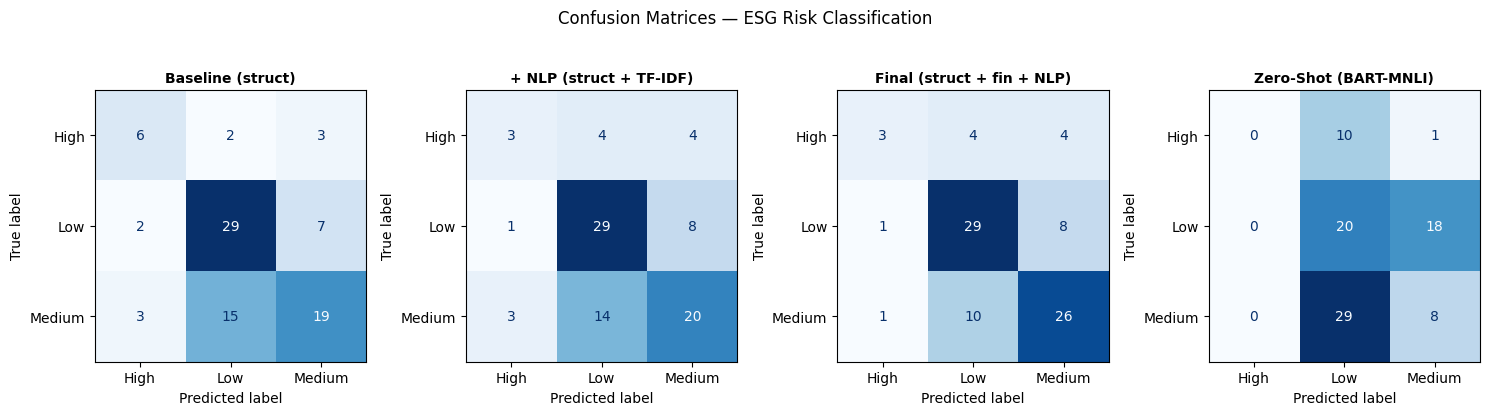

Saved: confusion_matrices.png


In [11]:
# ── 8. Evaluation: confusion matrix heatmap ───────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
models_preds = [
    ("Baseline (struct)",         y_pred_baseline),
    ("+ NLP (struct + TF-IDF)",   y_pred_nlp),
    ("Final (struct + fin + NLP)", y_pred_final),
    ("Zero-Shot (BART-MNLI)",    y_pred_zeroshot),
]
labels = sorted(y_test.unique())

for ax, (title, y_pred) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title, fontsize=10, fontweight="bold")

plt.suptitle("Confusion Matrices — ESG Risk Classification", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrices.png")


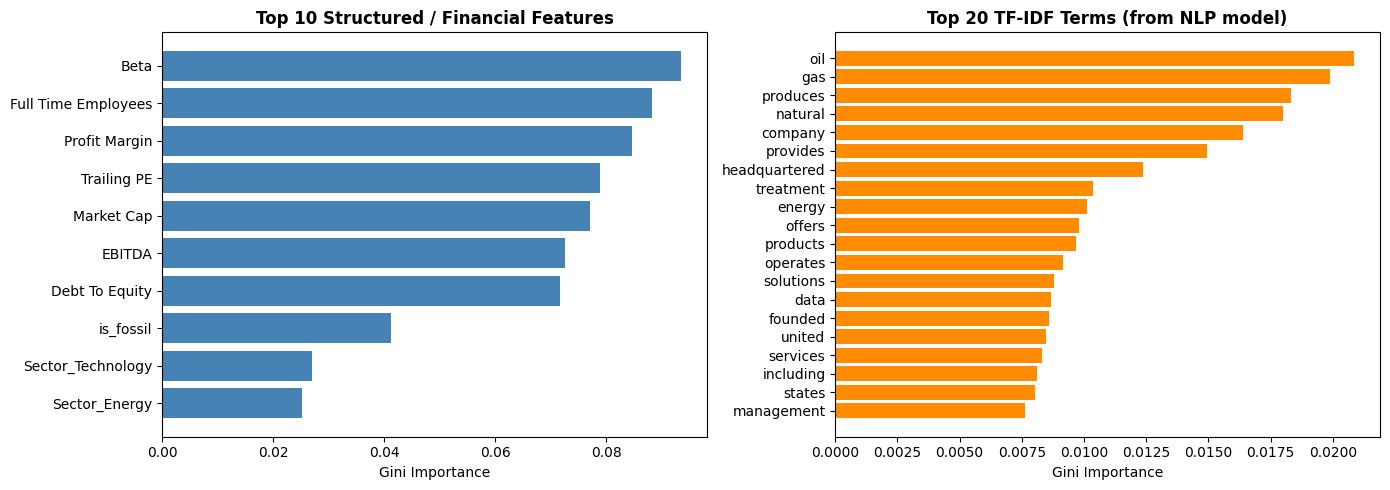

Saved: feature_importances.png

── Top 10 structured/financial features ──
            Feature  Importance
               Beta    0.093400
Full Time Employees    0.088108
      Profit Margin    0.084557
        Trailing PE    0.078800
         Market Cap    0.077012
             EBITDA    0.072598
     Debt To Equity    0.071585
          is_fossil    0.041194
  Sector_Technology    0.027061
      Sector_Energy    0.025161

── Top 20 TF-IDF terms ──
         Term  Importance
          oil    0.020852
          gas    0.019904
     produces    0.018337
      natural    0.018011
      company    0.016378
     provides    0.014941
headquartered    0.012368
    treatment    0.010352
       energy    0.010134
       offers    0.009786
     products    0.009660
     operates    0.009160
    solutions    0.008789
         data    0.008683
      founded    0.008588
       united    0.008477
     services    0.008329
    including    0.008114
       states    0.008033
   management    0.007626


In [12]:
# ── 9. Feature importance ─────────────────────────────────────────────────────

# 2 plots:
#   A) Top 10 structured/financial features (from a dedicated dense RF)
#   B) Top 20 TF-IDF terms (from the NLP RF)


# A) Structured + financial features
rf_interp = RandomForestClassifier(
    n_estimators=200, random_state=RANDOM_STATE,
    class_weight="balanced", n_jobs=-1
)
# Get feature names from the ColumnTransformer
ohe_names  = preprocessor_final.named_transformers_["cat"].get_feature_names_out(cat_features)
feature_names_sf = list(ohe_names) + all_num_features

X_train_sf_dense = X_train_sf.toarray()
rf_interp.fit(X_train_sf_dense, y_train)

fi_df = (
    pd.DataFrame({"Feature": feature_names_sf, "Importance": rf_interp.feature_importances_})
    .sort_values("Importance", ascending=False)
    .head(10)
)

# B) TF-IDF terms
tfidf_importances = rf_nlp.feature_importances_
n_struct = X_train_struct.shape[1]
tfidf_imp_only = tfidf_importances[n_struct:]  # slice off structured part
tfidf_terms = tfidf.get_feature_names_out()
fi_tfidf = (
    pd.DataFrame({"Term": tfidf_terms, "Importance": tfidf_imp_only})
    .sort_values("Importance", ascending=False)
    .head(20)
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(fi_df["Feature"][::-1], fi_df["Importance"][::-1], color="steelblue")
axes[0].set_title("Top 10 Structured / Financial Features", fontweight="bold")
axes[0].set_xlabel("Gini Importance")

axes[1].barh(fi_tfidf["Term"][::-1], fi_tfidf["Importance"][::-1], color="darkorange")
axes[1].set_title("Top 20 TF-IDF Terms (from NLP model)", fontweight="bold")
axes[1].set_xlabel("Gini Importance")

plt.tight_layout()
plt.savefig("feature_importances.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: feature_importances.png")

print("\n── Top 10 structured/financial features ──")
print(fi_df.to_string(index=False))

print("\n── Top 20 TF-IDF terms ──")
print(fi_tfidf.to_string(index=False))


In [13]:
# ── 10. Model comparison summary ──────────────────────────────────────────────

from sklearn.metrics import f1_score, accuracy_score

summary = pd.DataFrame([
    {
        "Model": "Baseline (struct)",
        "Features": "Sector, Industry, Employees",
        "Accuracy": accuracy_score(y_test, y_pred_baseline),
        "F1-macro": f1_score(y_test, y_pred_baseline, average="macro"),
    },
    {
        "Model": "+ NLP",
        "Features": "+ TF-IDF descriptions (300 terms)",
        "Accuracy": accuracy_score(y_test, y_pred_nlp),
        "F1-macro": f1_score(y_test, y_pred_nlp, average="macro"),
    },
    {
        "Model": "Final",
        "Features": "+ Market Cap, EBITDA, PE, Beta, Margins, D/E",
        "Accuracy": accuracy_score(y_test, y_pred_final),
        "F1-macro": f1_score(y_test, y_pred_final, average="macro"),
    },
    {
        "Model": "Zero-Shot (BART-MNLI)",
        "Features": "Text ONLY (No training / Zero-Shot)",
        "Accuracy": accuracy_score(y_test, y_pred_zeroshot),
        "F1-macro": f1_score(y_test, y_pred_zeroshot, average="macro"),
    }
])

summary[["Accuracy", "F1-macro"]] = summary[["Accuracy", "F1-macro"]].round(3)
print("\n── Model comparison ──")
print(summary.to_string(index=False))



── Model comparison ──
                Model                                     Features  Accuracy  F1-macro
    Baseline (struct)                  Sector, Industry, Employees     0.628     0.604
                + NLP            + TF-IDF descriptions (300 terms)     0.605     0.532
                Final + Market Cap, EBITDA, PE, Beta, Margins, D/E     0.674     0.595
Zero-Shot (BART-MNLI)          Text ONLY (No training / Zero-Shot)     0.326     0.221
